<a href="https://colab.research.google.com/github/thisismemayanka/analysis-projects/blob/main/Analyzing_the_Dynamic_Impact_of_Monetary_Policy_Shocks_on_Inflation_and_Unemployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fredapi

In [ ]:
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

In [ ]:

fred = Fred(api_key='64d1abbe4cb6e71ea8b505fe63fc0684') # Re-initializing fred with the correct API key.

data = pd.DataFrame({
    'interest_rate': fred.get_series('FEDFUNDS'),
    'cpi': fred.get_series('CPIAUCSL'),
    'unemployment': fred.get_series('UNRATE')
})

data = data.dropna()
data

,interest_rate,cpi,unemployment
1954-07-01,0.80,26.860,5.8
1954-08-01,1.22,26.850,6.0
1954-09-01,1.07,26.810,6.1
1954-10-01,0.85,26.720,5.7
1954-11-01,0.83,26.780,5.3
...,...,...,...
2026-01-01,3.64,326.588,4.3
2026-02-01,3.64,327.460,4.4
2026-03-01,3.64,330.293,4.3
2026-04-01,3.64,332.407,4.3


In [ ]:
# 2. Define the Series ID (e.g., 'GDP' for Gross Domestic Product)
series_id = 'GDP'

# 3. Fetch all columns and releases
# 'get_series_all_releases' returns a DataFrame containing realtime_start, realtime_end, date, and value
df = fred.get_series_all_releases(series_id)
df

,realtime_start,date,value
0,1992-12-22 00:00:00,1946-01-01 00:00:00,199.7
1,1996-01-19 00:00:00,1946-01-01 00:00:00,NaT
2,1997-05-07 00:00:00,1946-01-01 00:00:00,210.4
3,1999-10-28 00:00:00,1946-01-01 00:00:00,NaT
4,1992-12-22 00:00:00,1946-04-01 00:00:00,207.7
...,...,...,...
3233,2026-02-20 00:00:00,2025-10-01 00:00:00,31490.07
3234,2026-03-13 00:00:00,2025-10-01 00:00:00,31442.483
3235,2026-04-09 00:00:00,2025-10-01 00:00:00,31422.526
3236,2026-04-30 00:00:00,2026-01-01 00:00:00,31856.257


In [ ]:
fred.get_series

<bound method Fred.get_series of <fredapi.fred.Fred object at 0x7cbd3f64dc70>>

In [ ]:
data.head(20)

,interest_rate,cpi,unemployment
1954-07-01,0.80,26.86,5.8
1954-08-01,1.22,26.85,6.0
1954-09-01,1.07,26.81,6.1
1954-10-01,0.85,26.72,5.7
1954-11-01,0.83,26.78,5.3


In [ ]:
data['inflation'] = data['cpi'].pct_change() * 100
data = data.dropna()

# Keep only required columns
data = data[['interest_rate', 'inflation', 'unemployment']]

# Set monthly frequency
data = data.asfreq('MS')

# Fill missing values
data = data.interpolate()
data = data.loc['1985-01-01':'2024-12-01']

print(data.info())
print(data.index.freq)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 480 entries, 1985-01-01 to 2024-12-01
Freq: MS
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   interest_rate  480 non-null    float64
 1   inflation      480 non-null    float64
 2   unemployment   480 non-null    float64
dtypes: float64(3)
memory usage: 15.0 KB
None
<MonthBegin>


In [ ]:
data.head()

,interest_rate,inflation,unemployment
1985-01-01,8.35,0.189573,7.3
1985-02-01,8.50,0.567644,7.2
1985-03-01,8.58,0.470367,7.2
1985-04-01,8.27,0.187266,7.3
1985-05-01,7.97,0.186916,7.2


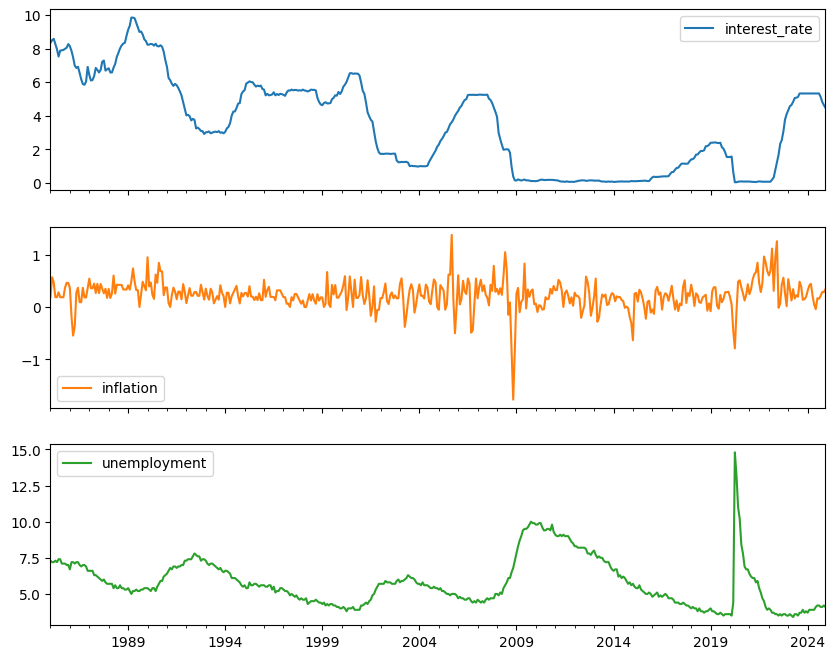

In [ ]:
data.plot(subplots=True, figsize=(10,8))
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series)
    print(f"{name}: p-value = {result[1]}")

for col in data.columns:
    adf_test(data[col], col)

interest_rate: p-value = 0.14302612885961602
inflation: p-value = 0.001834252813664674
unemployment: p-value = 0.04769007780795662


In [ ]:
data['interest_rate'] = data['interest_rate'].diff()
data = data.dropna()

In [ ]:
for col in data.columns:
    adf_test(data[col], col)

interest_rate: p-value = 1.4825696618318395e-06
inflation: p-value = 0.0016952073318705066
unemployment: p-value = 0.04560288800695121


In [ ]:

from statsmodels.tsa.api import VAR

model = VAR(data)

lag_order = model.select_order(maxlags=12)

print(lag_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -4.894      -4.868    0.007488      -4.884
1       -7.868     -7.762*   0.0003826      -7.827
2       -7.906      -7.719   0.0003687     -7.832*
3      -7.934*      -7.668  0.0003582*      -7.830
4       -7.907      -7.561   0.0003681      -7.771
5       -7.913      -7.487   0.0003661      -7.745
6       -7.883      -7.377   0.0003771      -7.684
7       -7.866      -7.280   0.0003838      -7.635
8       -7.847      -7.181   0.0003911      -7.585
9       -7.829      -7.083   0.0003984      -7.535
10      -7.810      -6.985   0.0004057      -7.485
11      -7.777      -6.872   0.0004194      -7.421
12      -7.774      -6.789   0.0004209      -7.386
--------------------------------------------------


In [ ]:
var_model = model.fit(lag_order.selected_orders['aic'])

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 14, May, 2026
Time:                     06:25:21
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -7.67221
Nobs:                     476.000    HQIC:                  -7.83151
Log likelihood:          -107.776    FPE:                0.000358091
AIC:                     -7.93474    Det(Omega_mle):     0.000336439
--------------------------------------------------------------------
Results for equation interest_rate
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -0.006131         0.031312           -0.196           0.845
L1.interest_rate         0.493931         0.046130           10.707           0.000
L1.inflation            -0.006060       

In [ ]:
print(var_model.is_stable())

True


In [ ]:
print(acorr_ljungbox(var_model.resid['inflation'], lags=[12]))

      lb_stat  lb_pvalue
12  21.991837   0.037611


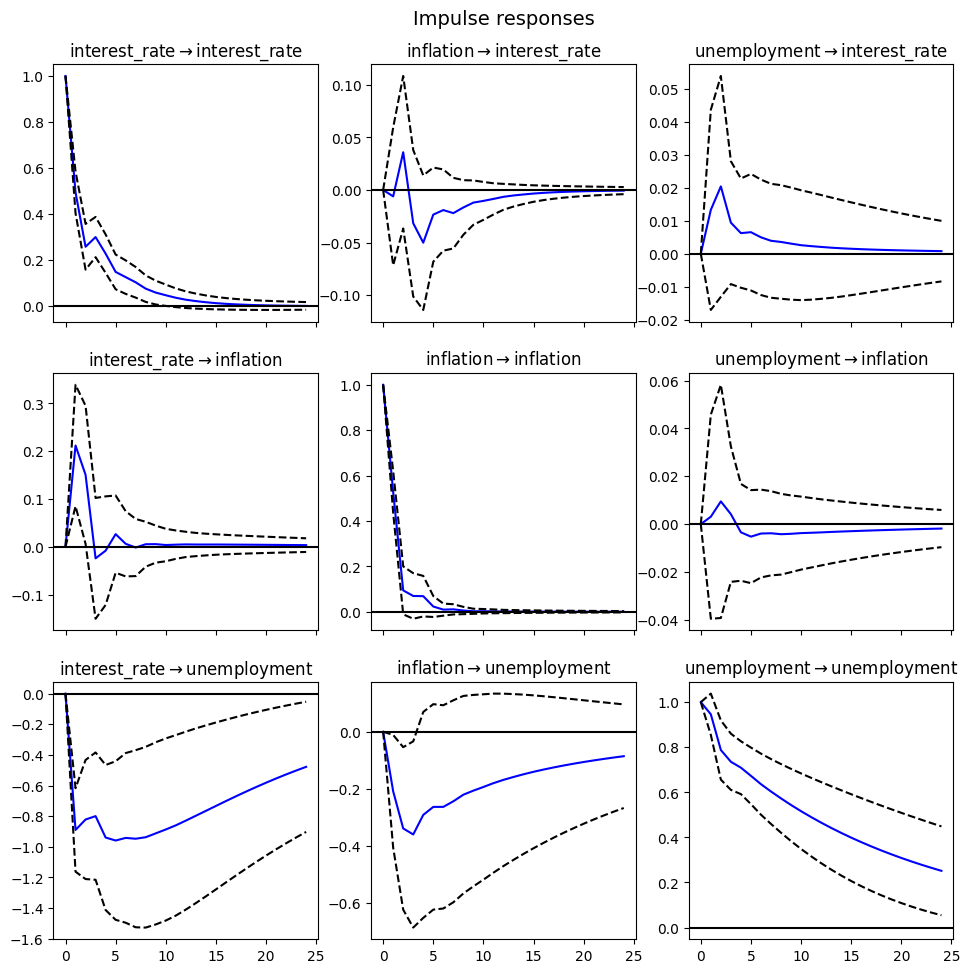

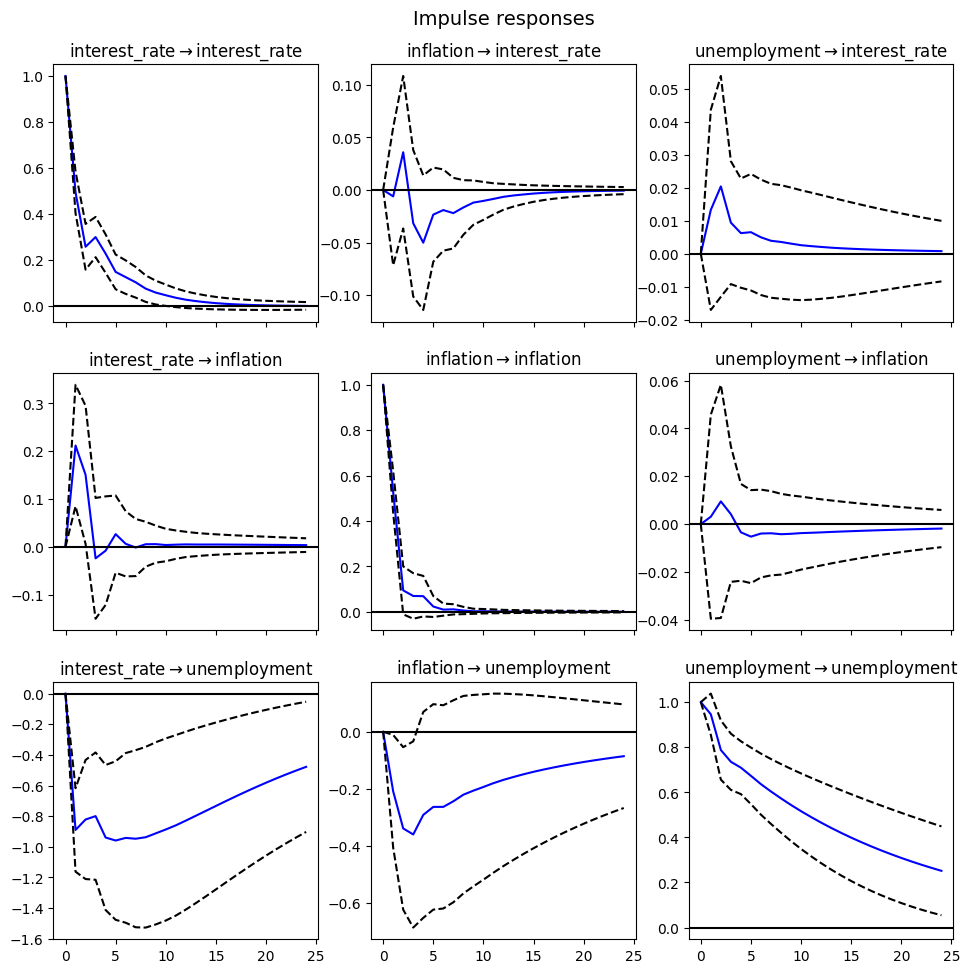

In [ ]:
irf = var_model.irf(24)

irf.plot(orth=False, signif=0.05)


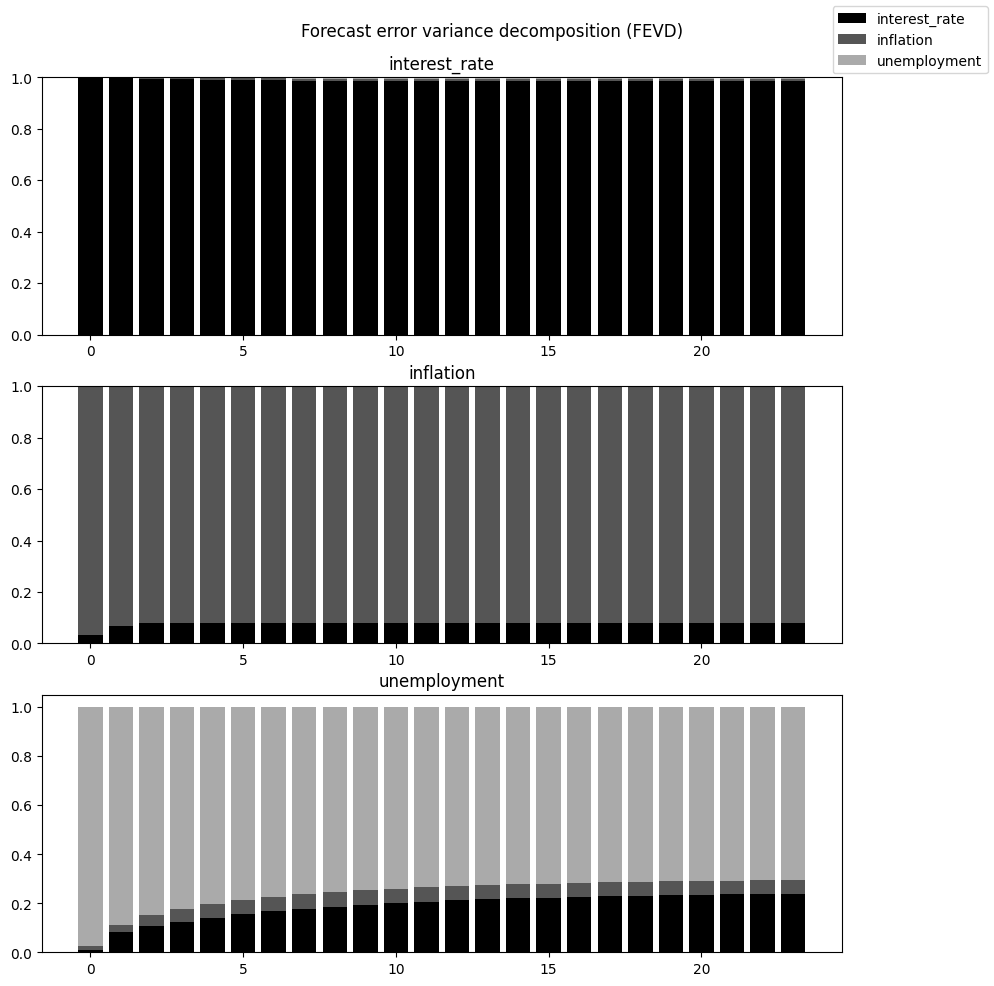

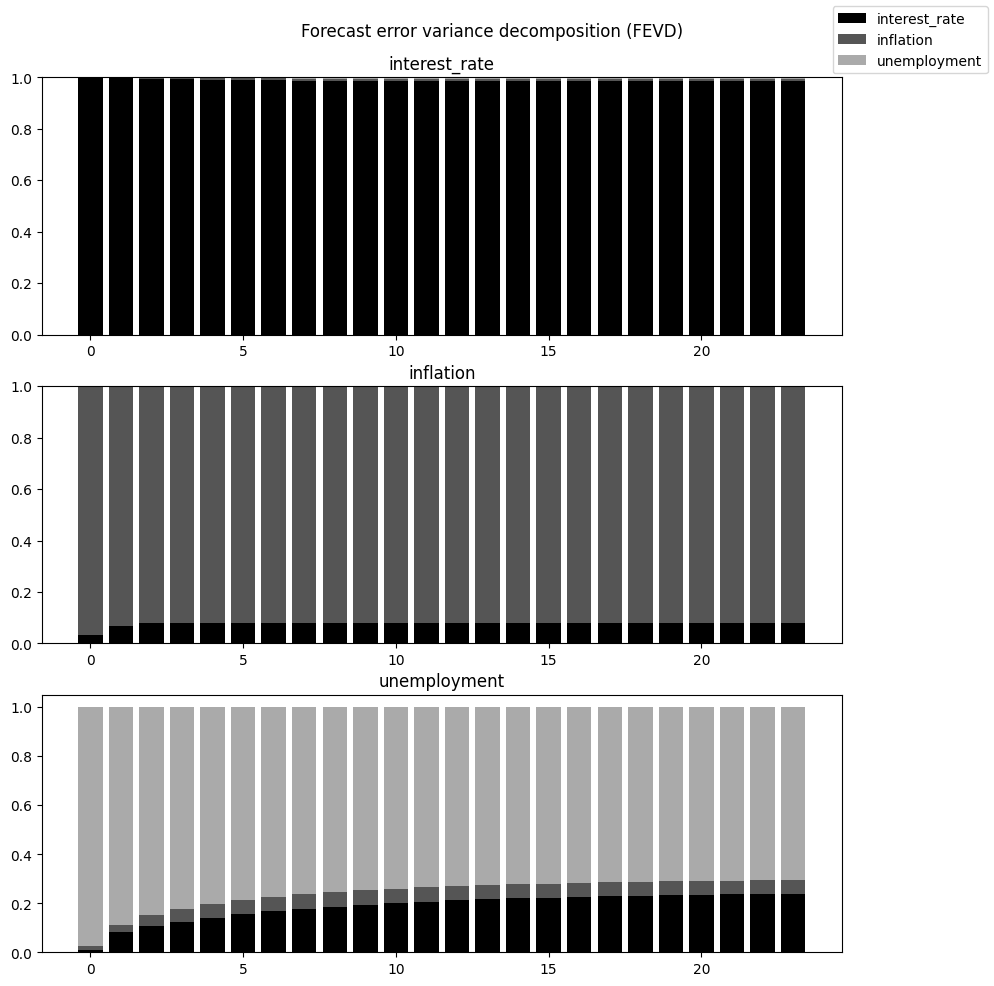

In [ ]:
fevd = var_model.fevd(24)
fevd.plot()

In [ ]:
from statsmodels.tsa.vector_ar.svar_model import SVAR
import numpy as np

A = [
    [1, 0, 0],
    ['E', 1, 0],
    ['E', 'E', 1]]

svar_model = SVAR(data, svar_type='A', A=np.array(A))

svar_result = svar_model.fit(maxlags=5)

# Workaround for AttributeError: 'SVARResults' object has no attribute 'k_exog_user'
# The SVARResults object returned by fit() might not be initializing k_exog_user
# when no exog is provided. We explicitly set it to 0 as there are no exogenous variables.
if not hasattr(svar_result, 'k_exog_user'):
    svar_result.k_exog_user = 0

print(svar_result.summary())

  Summary of Regression Results   
Model:                        SVAR
Method:                        OLS
Date:           Thu, 14, May, 2026
Time:                     06:25:29
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -7.49316
Nobs:                     474.000    HQIC:                  -7.74882
Log likelihood:          -93.9835    FPE:                0.000365418
AIC:                     -7.91454    Det(Omega_mle):     0.000330778
--------------------------------------------------------------------
Results for equation interest_rate
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -0.028733         0.032893           -0.874           0.382
L1.interest_rate         0.462812         0.046951            9.857           0.000
L1.inflation             0.001571       

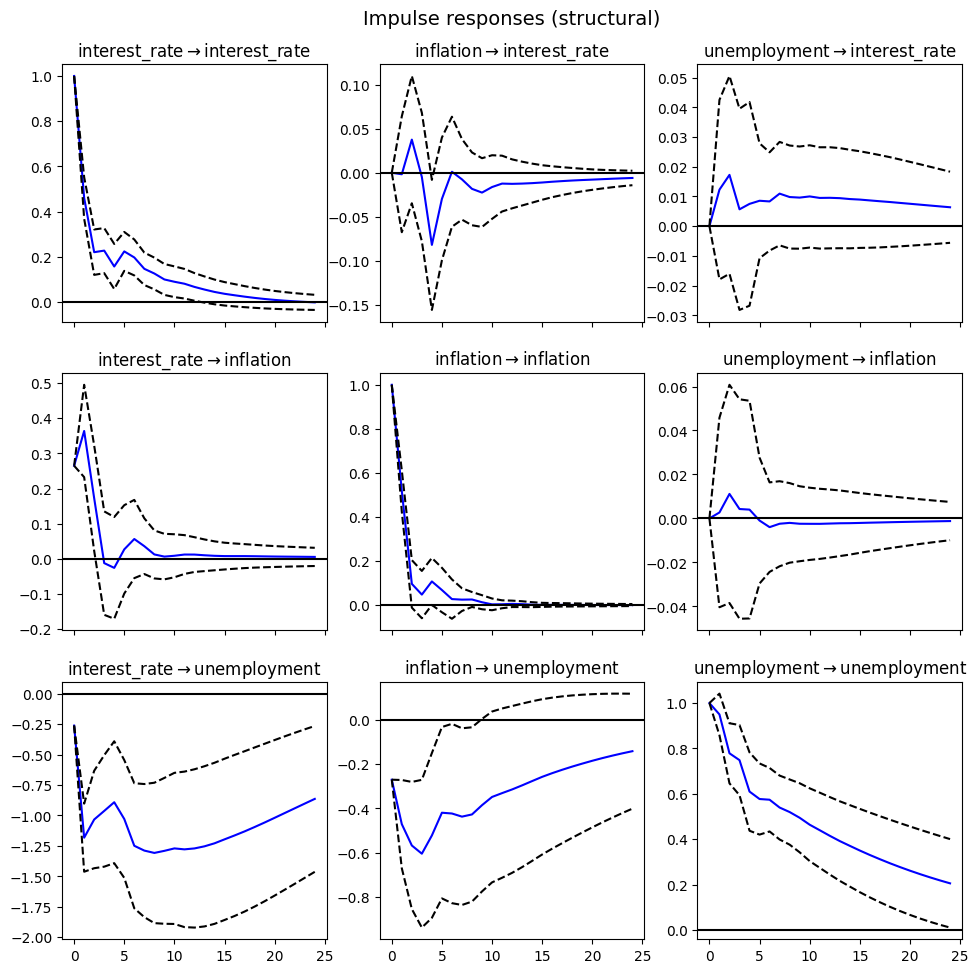

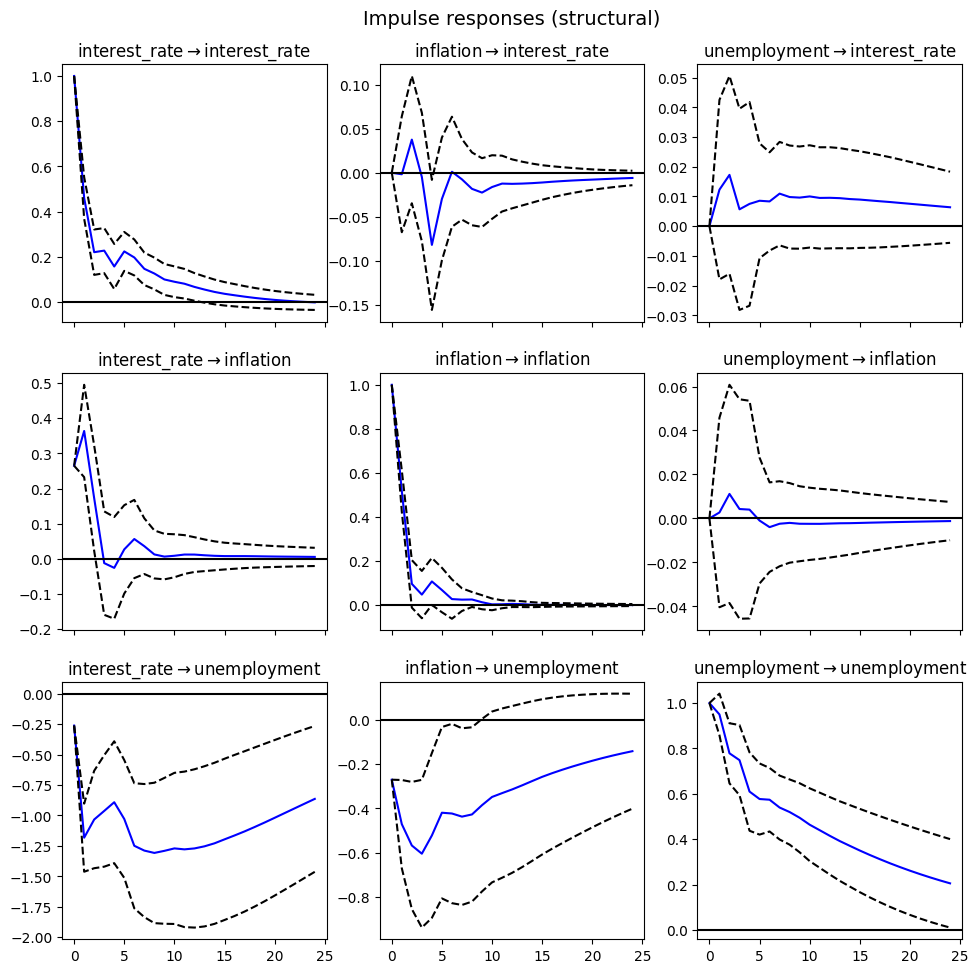

In [ ]:
svar_irf = svar_result.irf(24)

svar_irf.plot()